# Logistic Regression — Pima Indians Diabetes Dataset

This notebook demonstrates binary classification with logistic regression on the Pima Indians Diabetes dataset. By the end you will be able to:

- Handle physiologically impossible zero values through median imputation
- Compare an unregularised logistic model against an L2-regularised one
- Interpret precision, recall, and F1 via confusion matrices
- Plot and compare ROC curves with AUC annotations
- Visualise decision boundaries in 2D via PCA projection

## Mathematical Intuition

**Logistic regression** models the probability of class 1 using the sigmoid function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \mathbf{w}^\top \mathbf{x} + b$$

The model predicts $\hat{y} = 1$ when $\sigma(z) \geq 0.5$ (i.e. $z \geq 0$).

**Log-loss** (binary cross-entropy) is minimised during training:

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

**L2 regularisation** adds a penalty to the loss:

$$\mathcal{L}_{\text{ridge}}(\mathbf{w}) = \mathcal{L}(\mathbf{w}) + \frac{\alpha}{2} \|\mathbf{w}\|^2$$

- Larger $\alpha$ shrinks weights toward zero, reducing overfitting but potentially increasing bias.
- The gradient of the regularised loss with respect to $\mathbf{w}$ is $\nabla \mathcal{L} + \alpha \mathbf{w}$, which is used in gradient descent.

## Dataset Overview

The **Pima Indians Diabetes** dataset contains diagnostic measurements for 768 female patients of Pima Indian heritage.

| Feature | Type | Description |
|---------|------|-------------|
| Pregnancies | Continuous | Number of pregnancies |
| Glucose | Continuous | Plasma glucose concentration (2-hour oral glucose tolerance test) |
| BloodPressure | Continuous | Diastolic blood pressure (mm Hg) |
| SkinThickness | Continuous | Triceps skinfold thickness (mm) |
| Insulin | Continuous | 2-hour serum insulin (mu U/ml) |
| BMI | Continuous | Body mass index (kg/m²) |
| DiabetesPedigreeFunction | Continuous | Diabetes pedigree function score |
| Age | Continuous | Age (years) |
| **Outcome** | **Binary** | **1 = diabetic, 0 = non-diabetic — target** |

- **Rows:** 768  
- **Features:** 8  
- **Target:** Outcome (binary)  
- **Note:** zero values in several columns represent missing data, not true zeros

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlpackage import (
    LogisticRegression, PCA,
    StandardScaler, train_test_split,
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
)

sns.set_style("whitegrid")

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Exploratory Data Analysis

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Class balance:
Outcome
0    500
1    268
Name: count, dtype: int64


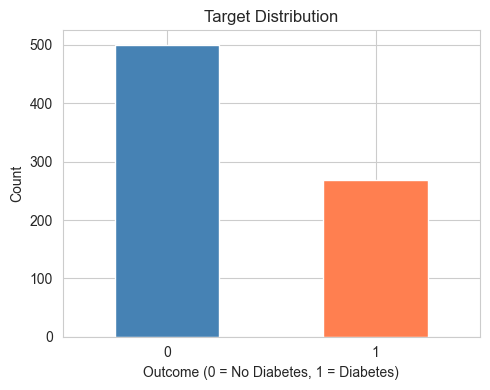

In [2]:
print(df.dtypes)
print("\nClass balance:")
print(df["Outcome"].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
df["Outcome"].value_counts().plot(kind="bar", color=["steelblue", "coral"], ax=ax)
ax.set_title("Target Distribution")
ax.set_xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
ax.set_ylabel("Count")
ax.set_xticklabels(["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

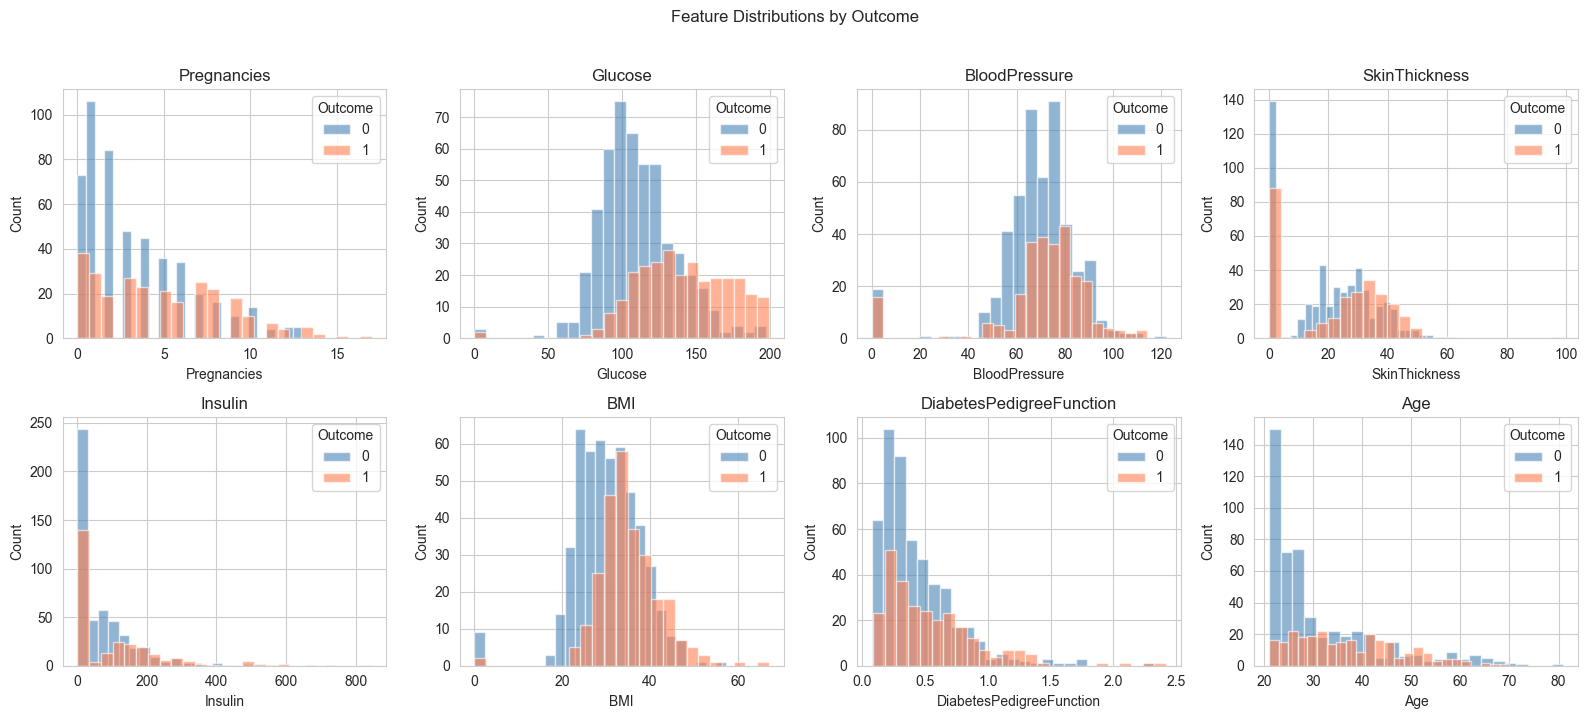

In [3]:
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), features):
    for outcome, color in [(0, "steelblue"), (1, "coral")]:
        ax.hist(df.loc[df["Outcome"] == outcome, col], bins=25,
                alpha=0.6, color=color, label=str(outcome), edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(title="Outcome")
plt.suptitle("Feature Distributions by Outcome", y=1.02)
plt.tight_layout()
plt.show()

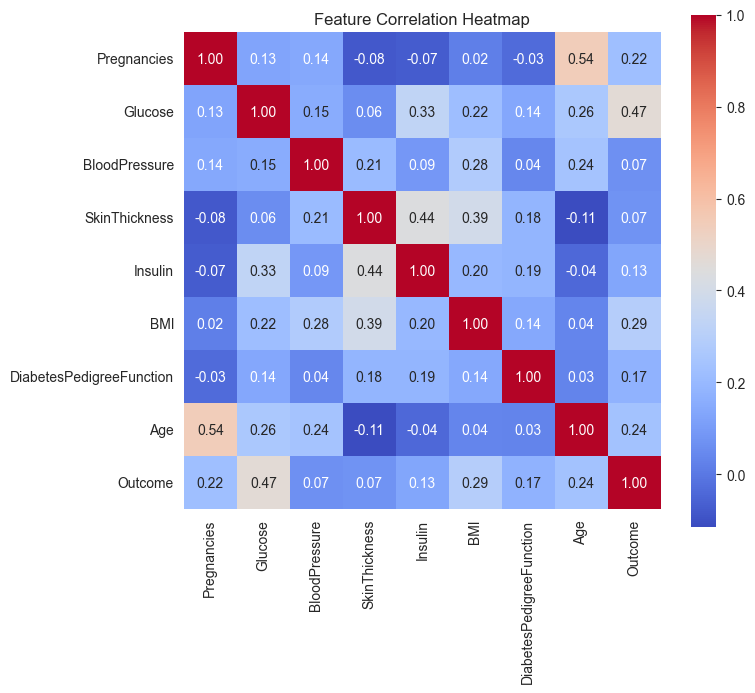

In [4]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing

Zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` are physiologically impossible — a person cannot have zero blood pressure or zero BMI. These zeros are therefore missing values encoded as zero in the original data collection. We replace them with each column's median (computed on the training set only after splitting) to avoid data leakage.

In [5]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X = df[features].copy()
y = df["Outcome"].values

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

X_train_df = pd.DataFrame(X_train, columns=features)
X_test_df  = pd.DataFrame(X_test,  columns=features)

for col in zero_cols:
    median_val = X_train_df.loc[X_train_df[col] != 0, col].median()
    X_train_df[col] = X_train_df[col].replace(0, median_val)
    X_test_df[col]  = X_test_df[col].replace(0, median_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df.values)
X_test_scaled  = scaler.transform(X_test_df.values)

print(f"Train size: {X_train_scaled.shape[0]}  |  Test size: {X_test_scaled.shape[0]}")

Train size: 614  |  Test size: 154


## Model Training

In [6]:
model_unreg = LogisticRegression(alpha=0.0, learning_rate=0.1, n_iterations=1000)
model_l2    = LogisticRegression(alpha=1.0, learning_rate=0.1, n_iterations=1000)

models = [("No regularisation (alpha=0)", model_unreg),
          ("L2 regularisation (alpha=1)", model_l2)]

for name, model in models:
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled,  y_test)
    print(f"{name:35s}  Train acc: {train_acc:.4f}  |  Test acc: {test_acc:.4f}")

No regularisation (alpha=0)          Train acc: 0.7866  |  Test acc: 0.6948
L2 regularisation (alpha=1)          Train acc: 0.7866  |  Test acc: 0.6948


## Evaluation

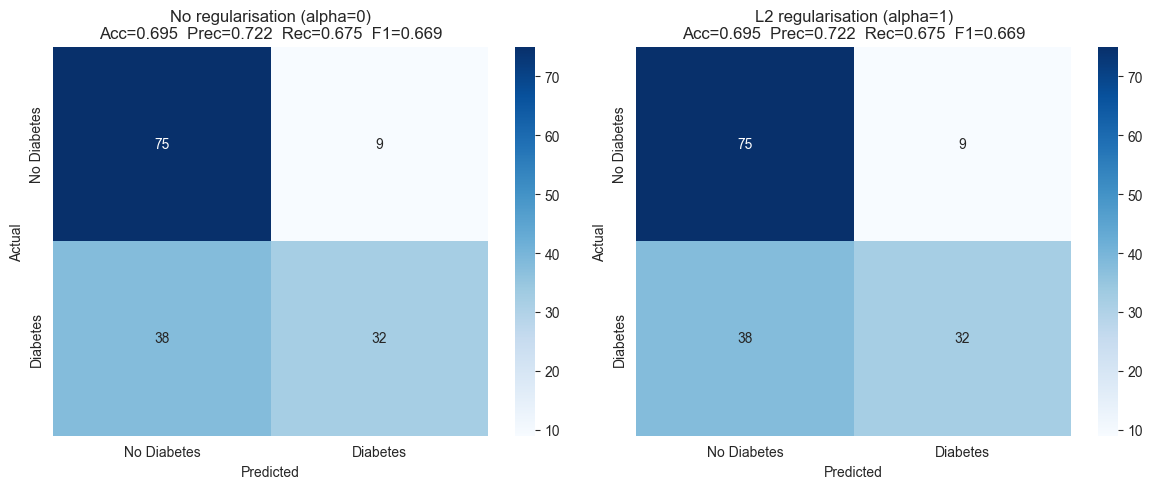


--- No regularisation (alpha=0) ---
   class   precision      recall    f1-score   support
------------------------------------------------------
       0        0.66        0.89        0.76        84
       1        0.78        0.46        0.58        70
------------------------------------------------------
weighted avg        0.72        0.69        0.68       154

--- L2 regularisation (alpha=1) ---
   class   precision      recall    f1-score   support
------------------------------------------------------
       0        0.66        0.89        0.76        84
       1        0.78        0.46        0.58        70
------------------------------------------------------
weighted avg        0.72        0.69        0.68       154


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, models):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    ax.set_title(f"{name}\nAcc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

for name, model in models:
    print(f"\n--- {name} ---")
    classification_report(y_test, model.predict(X_test_scaled))

## Visualisations

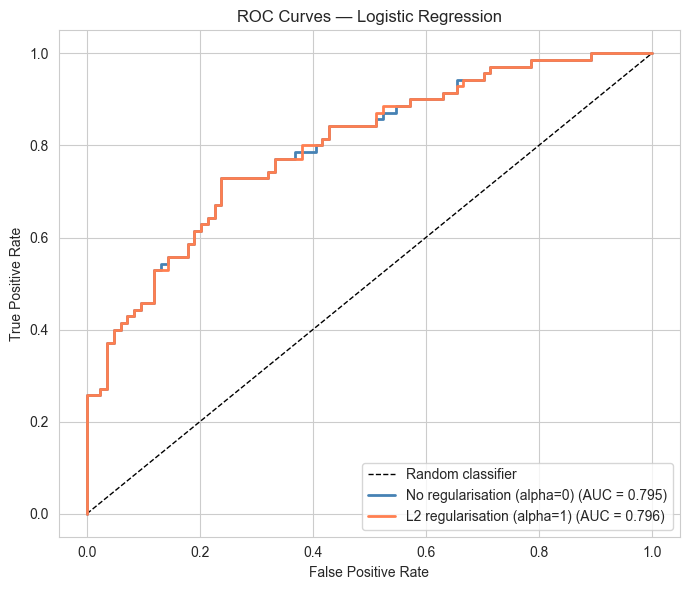

In [8]:
# ROC curves for both models on the same axes
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")

colors = ["steelblue", "coral"]
for (name, model), color in zip(models, colors):
    fpr, tpr, _ = model.roc_curve(X_test_scaled, y_test)
    auc_val     = model.auc(X_test_scaled, y_test)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {auc_val:.3f})")

ax.set_title("ROC Curves — Logistic Regression")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

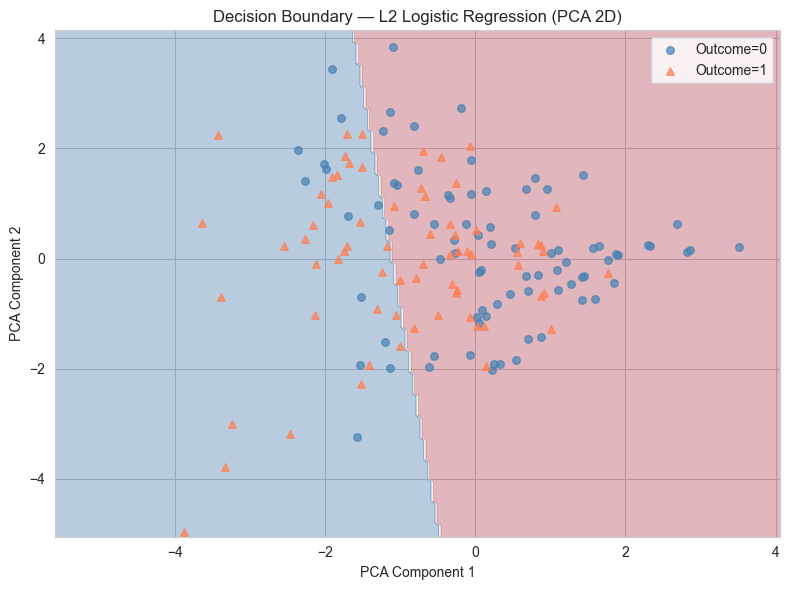

In [9]:
# Decision boundary in 2D via PCA
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)
X_test_2d  = pca_2d.transform(X_test_scaled)

lr_2d = LogisticRegression(alpha=1.0, learning_rate=0.1, n_iterations=1000)
lr_2d.fit(X_train_2d, y_train)

h = 0.05
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = lr_2d.predict(grid_points).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
for outcome, color, marker in [(0, "steelblue", "o"), (1, "coral", "^")]:
    mask = y_test == outcome
    ax.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
               c=color, marker=marker, s=30, alpha=0.7, label=f"Outcome={outcome}")
ax.set_title("Decision Boundary — L2 Logistic Regression (PCA 2D)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation and Conclusions

- **Median imputation was necessary** for five features (Glucose, BloodPressure, SkinThickness, Insulin, BMI) where zeros are biologically impossible. Leaving zeros in would have biased the mean and standard deviation used by StandardScaler.

- **Both models achieve train accuracy of ~79% and test accuracy of ~69.5%.** The small gap between train and test accuracy suggests modest overfitting, and L2 regularisation provides no measurable benefit here — both alpha=0 and alpha=1 produce identical predictions, indicating the unpenalised solution is already well-conditioned on 614 training samples.

- **Recall for class 1 (diabetic) is the critical metric** in this clinical context — a false negative (predicting no diabetes when there is diabetes) is more costly than a false positive. Both models achieve recall of only 0.46 for the positive class, meaning more than half of diabetic patients are missed. Precision for class 1 is 0.78, yielding an F1 of 0.58 — substantially below the negative-class F1 of 0.76.

- **The ROC curves lie above the random baseline**, confirming that logistic regression captures genuine signal in the data despite the class imbalance (~35% positive rate).

- **The PCA decision boundary** is linear in the 2D projection — logistic regression always produces a hyperplane, and PCA simply rotates the space so we can see it. The overlap in the two-component projection confirms why perfect separation is not achievable with a linear model on this dataset.
